# Debt Collection: Notification Effectiveness

## 1. Setup

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [47]:
data = pd.read_csv("dataset.csv")

C:\Users\meirz\AppData\Local\Temp\ipykernel_110164\2417667175.py:1: DtypeWarning: Columns (14,21,69) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("dataset.csv")


## 2. General info

**Общая информация:** 769 582 записей, 78 параметров

In [48]:
data.head(20)

,Unnamed: 0,contract_number,comm_date,notificationtype,notificationname,bin_iin,act_date,agreement_unq,agreem_state,contract_amount,...,attr__chld__cnt,attr__marital_status_name__categorial,attr__education_namee__categorial,attr__speciality_name__categorial,attr__birthplace_namee__categorial,attr__realty_owner_name__categorial,attr__branch_experience,attr__car_owner_name__categorial,attr__branch_product_name__categorial,attr__passed_days
0,0,77oК1t1119r117--140Эe190F9,2024-12-19,PUSH,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-19,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2159.0
1,1,77oК1t1119r117--140Эe190F9,2024-12-19,SMS,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-19,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2159.0
2,2,77oК1t1119r117--140Эe190F9,2024-12-20,PUSH,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2160.0
3,3,77oК1t1119r117--140Эe190F9,2024-12-20,PUSH,2-3-4-5 день Push-уведомление,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2160.0
4,4,77oК1t1119r117--140Эe190F9,2024-12-20,SMS,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2160.0
5,5,77oК1t1119r117--140Эe190F9,2024-12-21,PUSH,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2161.0
6,6,77oК1t1119r117--140Эe190F9,2024-12-21,PUSH,2-3-4-5 день Push-уведомление,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2161.0
7,7,77oК1t1119r117--140Эe190F9,2024-12-21,SMS,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-20,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2161.0
8,8,77oК1t1119r117--140Эe190F9,2024-12-22,PUSH,1-5 день Push/SMS-уведомление-2,030486380282,2024-12-23,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2162.0
9,9,77oК1t1119r117--140Эe190F9,2024-12-22,PUSH,2-3-4-5 день Push-уведомление,030486380282,2024-12-23,19;55168452458,Актуален,6075297.0,...,0.0,-1,высшее,Химической промышленности,МАНГИСТАУСКАЯ ОБЛАСТЬ,НЕТ,108.0,НЕТ,"Филиал АО ""ForteBank"" г. Актау",2162.0


In [49]:
data.columns

Index(['Unnamed: 0', 'contract_number', 'comm_date', 'notificationtype',
       'notificationname', 'bin_iin', 'act_date', 'agreement_unq',
       'agreem_state', 'contract_amount', 'open_date', 'close_date',
       'liquidate_date', 'currency', 'sign_restructing', 'branch_code',
       'branch_name', 'dept_code', 'dept_name', 'loan_purpose_code',
       'loan_purpose_name', 'collector_company', 'product_code',
       'product_name', 'customerid', 'ip_code', 'cr_line_id', 'interest_rate',
       'eff_interest_rate', 'delay_count_main', 'delay_count_percent',
       'credit_type', 'port_type', 'report', 'balance_main_dbt_amt',
       'balance_main_dbt_amt_in_lcl_ccy', 'balance_int_amt',
       'balance_int_amt_in_lcl_ccy', 'balance_odue_main_dbt_amt',
       'balance_odue_main_dbt_amt_in_lcl_ccy', 'balance_odue_int_amt',
       'balance_odue_int_amt_in_lcl_ccy', 'next_payment_date',
       'pps_of_issu_code', 'pps_of_issu_nm', 'z_good', 'sign_ref',
       'cr_mgr_code', 'cr_mgr_nm', 'pl

## 3. Data Preprocessing

### 3.1 Создаем новый датасет с отфильтрованными данными

In [50]:
data_filtered_columns = data[['contract_number', 'comm_date', 'notificationtype', 'notificationname', 
                              'contract_amount', 'open_date', 'delay_count_main', 'delay_count_percent', 
                              'balance_odue_main_dbt_amt', 'interest_rate', 'eff_interest_rate', 'balance_odue_int_amt', 
                              'next_payment_date', 'attr__gender__categorical', 'attr__city__categorical', 'attr__age', 
                              'attr__age__categorical', 'attr__chld__cnt', 'attr__passed_days']]

### 3.2 Первичные манипуляции

Удалим всех клиентов, у которых никогда не было задолженности, i.e. keep only customers with at least one non-zero `delay_count_main`.

In [51]:
data = data_filtered_columns.groupby('contract_number').filter(lambda x: not x['delay_count_main'].isna().all()) # keep those who have at least 1 non-Nan value
data = data.groupby('contract_number').filter(lambda x: not (x['delay_count_main'] == 0).all()) # keep those who have at least 1 non-zero value

Если `delay_count_main` = NaN, но `balance_odue_main_dbt_amt` = 0, то `delay_count_main` = 0. Если нет долга, то счетчик просроченных дней отключается.

In [52]:
data.loc[(data['delay_count_main'].isna()) & (data['balance_odue_main_dbt_amt'] == 0), 'delay_count_main'] = 0  # If debt is zero the counter of delay_count_main is set to zero

Если `delay_count_main` = NaN, но `delay_count_percent` ≠ NaN, то `delay_count_main` = `delay_count_percent`.

In [53]:
data['delay_count_main'] = data['delay_count_main'].fillna(data['delay_count_percent']) # Fill empty delay_count_main with values from delay_count_percent - they replicate values ost of the times (80+%)
data = data.drop(columns = ['delay_count_percent']) # Get rid of delay_count_percent

If `balance_odue_main_dbt_amt`, `delay_count_main` and `next_payment_date` are all empty, delete the row, because no valuable information can be derived.

In [54]:
data = data.dropna(subset=['balance_odue_main_dbt_amt', 'delay_count_main', 'next_payment_date'], how='all')

Sort the data by `contract_number`, then by `comm_date`.

In [55]:
data = data.sort_values(by = ['contract_number', 'comm_date'], ascending=[True, True])

#### Encoding reference

| Age | Code |
|---|---|
| 18–25 | 1 (A) |
| 26–35 | 2 (B) |
| 36–45 | 3 (C) |
| 46–55 | 4 (D) |
| 56–65 | 5 (E) |
| >65 | 6 (F) |

| Gender | Code |
|---|---|
| Male | 0 (M) |
| Female | 1 (F) |

### 3.3 Feature: `is_reduced`

If, after the last communication where there was debt, the next record shows a decrease in debt, this record is assigned `is_reduced = 1`, otherwise `is_reduced = 0`.

In [56]:
data['prev_debt'] = data.groupby('contract_number')['balance_odue_main_dbt_amt'].shift(1) # Helper-column
data['is_reduced'] = ((data['prev_debt'] > data['balance_odue_main_dbt_amt']) & (data['prev_debt'] > 0)).astype(int) # Previous debt > Current debt --> is_reduced = 1, o.w. is_reduced = 0

data.drop(columns=['prev_debt'], inplace=True) # Drop the helper

### 3.4 Sequences

Divide the dataset into complete — 1 (`'A'`) and incomplete — 0 (`'B'`) sequences, then assign each sequence a unique `sequence_index`.

In [57]:
# Introduce new features --
data['sequence_status'] = 'Incomplete'
data['sequence_index'] = -1  

sequence_counter = 0 
start_idx = None  
current_contract = None

for i in data.index: # Iterate through each row
    is_reduced = data.at[i, 'is_reduced']
    contract = data.at[i, 'contract_number']

    # Contract change --> mark previous seq as Incomplete if it hasn't been completed
    if contract != current_contract:
        if start_idx is not None:  # Mark last seq before switch
            data.loc[start_idx:prev_idx, ['sequence_status', 'sequence_index']] = ['Incomplete', sequence_counter]
            sequence_counter += 1  
        current_contract = contract  # upd to new contract
        start_idx = i  # New seq

    if is_reduced == 1:
        if start_idx is not None:  # if seq is running
            data.loc[start_idx:prev_idx, ['sequence_status', 'sequence_index']] = ['Complete', sequence_counter]
            sequence_counter += 1  # Move to next seq
        start_idx = i  # start new seq after this row

    prev_idx = i  # track last processed row

# assign sequence index to the last seq
if start_idx is not None and data.at[start_idx, 'sequence_status'] == 'Incomplete':
    data.loc[start_idx:, ['sequence_status', 'sequence_index']] = ['Incomplete', sequence_counter]
    sequence_counter += 1 

Fill in missing `delay_count_main` values within each sequence, based on the notification type.

In [58]:
def get_initial_value(x):
    """
    This function fills the number of missed days based on the type of notification that was sent to the user
    """
    if x in ('1-5 день Push/SMS-уведомление-2', '1-5 день Push/SMS-уведомление'):
        return 1
    if x == '2-3-4-5 день Push-уведомление':
        return 2
    if x in ('5-день усиленный -2', '5-й день - усиленный'):
        return 5
    if x in ('16-й день (sms ссылка на Сайт)', 'SMS на 16 день'):
        return 16
    if (x == '20-й день push'):
        return 20
    if (x == '30-й день push'):
        return 30
    if (x == '50-й день push'):
        return 50
    if (x == '60-й день push'):
        return 60
    return None  # calls carry no day number


def assign_passed_days(group):
    mask = group['delay_count_main'].isna() # Replace "not-a-number" values with True and others with False
    if mask.any(): # Check if any items in mask are true
        initial_value = get_initial_value(group.loc[mask, 'notificationname'].iloc[0]) # Obtain the number of days we want to plug in
        if initial_value is not None:
            group.loc[mask, 'delay_count_main'] = initial_value + group.loc[mask, 'comm_date'].rank(method='first').astype(int) - 1
    return group

# Apply the function group by 'class'
data = data.groupby('sequence_index', group_keys=False).apply(assign_passed_days)

# Rows that are still empty (calls) take the nearest known value within the sequence
data['delay_count_main'] = data.groupby('sequence_index')['delay_count_main'].ffill()
data['delay_count_main'] = data.groupby('sequence_index')['delay_count_main'].bfill()

C:\Users\meirz\AppData\Local\Temp\ipykernel_110164\4132091253.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('sequence_index', group_keys=False).apply(assign_passed_days)


### 3.5 Fill in the gaps in `next_payment_date`

The missed payment was `delay_count_main` days before `comm_date`; payments are due every ~30 days, so the next one is `comm_date − delay_count_main + 30 · ceil((delay_count_main + 1) / 30)`.

In [59]:
data['comm_date'] = pd.to_datetime(data['comm_date'])

mask = data['next_payment_date'].isna() # Nan rows in next_payment_date

delay = data.loc[mask, 'delay_count_main']
days_to_next_payment = 30 * np.ceil((delay + 1) / 30) - delay

data.loc[mask, 'next_payment_date'] = data.loc[mask, 'comm_date'] + pd.to_timedelta(days_to_next_payment, unit='D')

Random data sample

In [60]:
sample_users = data['contract_number'].drop_duplicates().sample(n=3, random_state=21)
sampled_df = data[data['contract_number'].isin(sample_users)]
sampled_df

,contract_number,comm_date,notificationtype,notificationname,contract_amount,open_date,delay_count_main,balance_odue_main_dbt_amt,interest_rate,eff_interest_rate,...,next_payment_date,attr__gender__categorical,attr__city__categorical,attr__age,attr__age__categorical,attr__chld__cnt,attr__passed_days,is_reduced,sequence_status,sequence_index
233286,06К3131Э1-7217ro4F2t34e1-1,2024-10-18,PUSH,1-5 день Push/SMS-уведомление,4765167.0,2021-06-25,3.0,40309.86,20.99,23.5,...,2024-11-15,1.0,Астана,50.0,46-55,0.0,45582.0,0,Incomplete,15152
233287,06К3131Э1-7217ro4F2t34e1-1,2024-10-18,PUSH,2-3-4-5 день Push-уведомление,4765167.0,2021-06-25,3.0,40309.86,20.99,23.5,...,2024-11-15,1.0,Астана,50.0,46-55,0.0,45582.0,0,Incomplete,15152
233288,06К3131Э1-7217ro4F2t34e1-1,2024-10-19,PUSH,1-5 день Push/SMS-уведомление,4765167.0,2021-06-25,3.0,40309.86,20.99,23.5,...,2024-11-15,1.0,Астана,50.0,46-55,0.0,45583.0,0,Incomplete,15152
233444,06К3131Э1-7217ro4F2t34e1-1,2024-10-19,PUSH,2-3-4-5 день Push-уведомление,4765167.0,2021-06-25,3.0,40309.86,20.99,23.5,...,2024-11-15,1.0,Астана,50.0,46-55,0.0,45583.0,0,Incomplete,15152
513637,К20retЭ1o74-992971-173135F,2024-10-09,CALL,OK (Обработано)\n,2500000.0,2022-08-03,57.0,69900.42,25.99,33.1,...,2024-10-14,1.0,Астана,36.0,36-45,0.0,5064.0,0,Complete,79394
513638,К20retЭ1o74-992971-173135F,2024-10-10,CALL,OK (Обработано)\n,2500000.0,2022-08-03,58.0,69900.42,25.99,33.1,...,2024-10-14,1.0,Астана,36.0,36-45,0.0,5065.0,0,Complete,79394
513639,К20retЭ1o74-992971-173135F,2024-10-11,CALL,OK (Обработано)\n,2500000.0,2022-08-03,59.0,69900.42,25.99,33.1,...,2024-10-14,1.0,Астана,36.0,36-45,0.0,5066.0,0,Complete,79394
513640,К20retЭ1o74-992971-173135F,2024-10-12,PUSH,60-й день push,2500000.0,2022-08-03,59.0,69900.42,25.99,33.1,...,2024-10-14,1.0,Астана,36.0,36-45,0.0,5067.0,0,Complete,79394
513641,К20retЭ1o74-992971-173135F,2024-10-18,CALL,Answer (Отвечено оператором)\n,2500000.0,2022-08-03,66.0,104632.64,25.99,33.1,...,2024-11-13,1.0,Астана,36.0,36-45,0.0,5073.0,0,Complete,79394
513971,К20retЭ1o74-992971-173135F,2024-10-21,CALL,No Answer (Не отвечает)\n,2500000.0,2022-08-03,69.0,104632.64,25.99,33.1,...,2024-11-13,1.0,Астана,36.0,36-45,0.0,5076.0,0,Complete,79394


## 4. Handling Missing Values

Which cells are still empty?

In [61]:
print(data.isna().sum().reset_index().rename(columns={'index': 'Column', 0: 'NaN Count'}))

                       Column  NaN Count
0             contract_number          0
1                   comm_date          0
2            notificationtype          0
3            notificationname          0
4             contract_amount          0
5                   open_date          0
6            delay_count_main          3
7   balance_odue_main_dbt_amt          0
8               interest_rate          0
9           eff_interest_rate          0
10       balance_odue_int_amt          0
11          next_payment_date          0
12  attr__gender__categorical      35748
13    attr__city__categorical      35748
14                  attr__age      35748
15     attr__age__categorical      35748
16            attr__chld__cnt      35748
17          attr__passed_days      35748
18                 is_reduced          0
19            sequence_status          0
20             sequence_index          0


### 4.1 Filling the empty attributes

Fill in `attr__passed_days` (`comm_date` − `open_date`).

In [62]:
data['comm_date'] = pd.to_datetime(data['comm_date'])
data['open_date'] = pd.to_datetime(data['open_date'])

data['attr__passed_days'] = (data['comm_date'] - data['open_date']).dt.days

#### Filling probabilistically

For future convenience, we introduce a function that fills the gaps.

In [63]:
def fill_probabilistically(df, user_col, categorical_cols):
    df_filled = df.copy()

    for cat_col in categorical_cols:
        value_distribution = df[cat_col].value_counts(normalize=True).to_dict() # Distribtuion of parameter

        def sample_value():
            return np.random.choice(list(value_distribution.keys()), p=list(value_distribution.values())) # pick one instance within the sample

        # seach for user with missing values in that category
        user_values = df.groupby(user_col)[cat_col].first()  # get first known value (if it exists)
        missing_users = user_values[user_values.isna()].index  # users with missing vals

        sampled_values = {user: sample_value() for user in missing_users} # assigning probablistically

        # fill missing valuesi n the dataframe
        df_filled[cat_col] = df_filled[user_col].map(lambda user: sampled_values.get(user, user_values[user]))

    return df_filled

Fill gender & city probabilistically.

In [64]:
categorical_columns = ['attr__gender__categorical', 'attr__city__categorical']
data = fill_probabilistically(data, 'contract_number', categorical_columns)

Fill in the ages (median, because the distribution is not normal).

In [65]:
median_age = data.drop_duplicates(subset=['contract_number', 'attr__age'])['attr__age'].median()
data['attr__age'].fillna(median_age, inplace=True)

def categorize_age(age):
    if age < 26:
        return '18-25'
    elif 26 <= age < 36:
        return '26-35'
    elif 36 <= age < 46:
        return '36-45'
    elif 46 <= age < 56:
        return '46-55'
    elif 56 <= age < 66:
        return '56-65'
    else:
        return '>65'

data['attr__age__categorical'] = data['attr__age'].apply(categorize_age)

C:\Users\meirz\AppData\Local\Temp\ipykernel_110164\860327375.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['attr__age'].fillna(median_age, inplace=True)


Assign the number of children accordingly & remove the outliers (`-1` means unknown, so it is treated as missing).

In [66]:
data['attr__chld__cnt'] = data['attr__chld__cnt'].replace(-1, np.nan)
data['attr__chld__cnt'] = data[data['attr__chld__cnt'] < 10]['attr__chld__cnt']

median_age = data.drop_duplicates(subset=['contract_number', 'attr__chld__cnt'])['attr__chld__cnt'].median()
data['attr__chld__cnt'].fillna(median_age, inplace=True)

C:\Users\meirz\AppData\Local\Temp\ipykernel_110164\1737102342.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['attr__chld__cnt'].fillna(median_age, inplace=True)


### 4.2 Sequence length

Add sequence length by recording the largest value of `delay_count_main`.

In [67]:
data["sequence_length"] = data.groupby("sequence_index")["delay_count_main"].transform("max")

Check on a random sample

In [68]:
sample_users = data['contract_number'].drop_duplicates().sample(n=3, random_state=21)
sampled_df = data[data['contract_number'].isin(sample_users)]
sampled_df[['contract_number', 'notificationname', 'is_reduced', 'sequence_status', 'sequence_index', 'sequence_length']]

,contract_number,notificationname,is_reduced,sequence_status,sequence_index,sequence_length
233286,06К3131Э1-7217ro4F2t34e1-1,1-5 день Push/SMS-уведомление,0,Incomplete,15152,3.0
233287,06К3131Э1-7217ro4F2t34e1-1,2-3-4-5 день Push-уведомление,0,Incomplete,15152,3.0
233288,06К3131Э1-7217ro4F2t34e1-1,1-5 день Push/SMS-уведомление,0,Incomplete,15152,3.0
233444,06К3131Э1-7217ro4F2t34e1-1,2-3-4-5 день Push-уведомление,0,Incomplete,15152,3.0
513637,К20retЭ1o74-992971-173135F,OK (Обработано)\n,0,Complete,79394,87.0
513638,К20retЭ1o74-992971-173135F,OK (Обработано)\n,0,Complete,79394,87.0
513639,К20retЭ1o74-992971-173135F,OK (Обработано)\n,0,Complete,79394,87.0
513640,К20retЭ1o74-992971-173135F,60-й день push,0,Complete,79394,87.0
513641,К20retЭ1o74-992971-173135F,Answer (Отвечено оператором)\n,0,Complete,79394,87.0
513971,К20retЭ1o74-992971-173135F,No Answer (Не отвечает)\n,0,Complete,79394,87.0


## 5. Machine Learning: Training the Models

### 5.0 Modelling dataset

Incomplete sequences are always the last ones of a contract, cut off by the end of the data export, so the length of a chain (and `sequence_length`) gives the class away. To avoid this leakage every model sees only the **first `n_first_actions` notifications** of a sequence, and only sequences that have at least that many.

Train/test is split by `contract_number`, so sequences of the same client never end up in both.

In [69]:
from sklearn.model_selection import GroupShuffleSplit

n_first_actions = 5

seq_size = data.groupby('sequence_index')['notificationname'].transform('size')
data_model = data[seq_size >= n_first_actions].groupby('sequence_index').head(n_first_actions)
data_model = data_model.drop(columns=['sequence_length'])

contract_of_sequence = data_model.groupby('sequence_index')['contract_number'].first()

def group_split(X, y, groups, test_size=0.2, random_state=42):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

data_model.groupby('sequence_index')['sequence_status'].first().value_counts()

sequence_status
Incomplete    25961
Complete      20692
Name: count, dtype: int64

### 5.1 Logistic Regression

In [70]:
data_logistic = data_model.copy()

In [71]:
data.shape

(673096, 22)

> **Note:** this approach doesn't take the order and the number of actions into account.

First, we transform the data using one-hot encoding.

In [72]:
# one-hot encoding on action_code
one_hot = pd.get_dummies(data_logistic['notificationname'])

df = pd.concat([data_logistic, one_hot], axis=1) # сoncatenate one-hot encoding with original dataframe

columns = ['contract_number', 'comm_date', 'notificationname', 'contract_amount', 'open_date', 'interest_rate', 'sequence_status', 'attr__gender__categorical', 'attr__city__categorical', 'attr__age', 'attr__age__categorical', 'attr__chld__cnt', 'attr__passed_days']

# Identify all feature columns dynamically except sequence_index, action_code, and days_passed
feature_columns = [col for col in columns if col not in ["sequence_index", "notificationname", "delay_count_main"] + list(one_hot.columns)]

# dynamic aggregation
agg_dict = {col: "first" for col in feature_columns}  # non-categorical features
agg_dict.update({col: "max" for col in one_hot.columns})  # one-hot encoded columns

df_final = df.groupby("sequence_index").agg(agg_dict).reset_index() # aggregate by seq index
groups = df_final['contract_number']

data_logistic = df_final.drop(columns = ['sequence_index', 'contract_number', 'comm_date', 'contract_amount',
       'open_date', 'interest_rate',
       'attr__gender__categorical', 'attr__city__categorical', 'attr__age',
       'attr__age__categorical', 'attr__chld__cnt', 'attr__passed_days'])

data_logistic['sequence_status'] = data_logistic['sequence_status'].map({'Incomplete': 0, 'Complete': 1})

#### Training the model

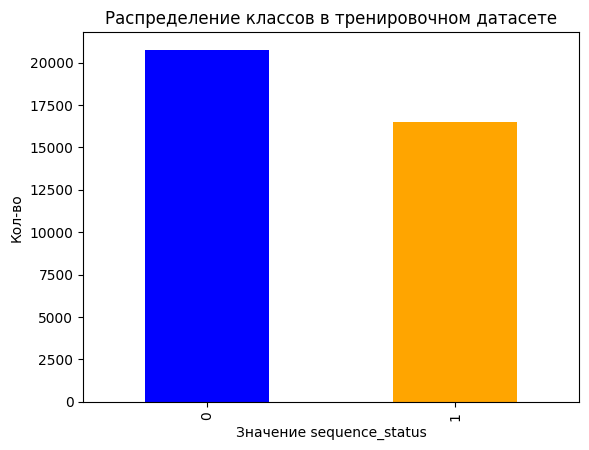

Accuracy: 0.6190
ROC-AUC Score: 0.6391
Precision: 0.6111
Recall: 0.3947
F1 Score: 0.4796


In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

X = data_logistic.drop(columns=['sequence_status'])  # Features
y = data_logistic['sequence_status']  # Target
X_train, X_test, y_train, y_test = group_split(X, y, groups)

y_train.value_counts().plot(kind="bar", color=['blue', 'orange'])
plt.xlabel("Значение sequence_status")
plt.ylabel("Кол-во")
plt.title("Распределение классов в тренировочном датасете")
plt.show()

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC Score: {roc_auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

#### Explaining with SHAP

Background dataset has 37282 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=37282 when initializing the masker.


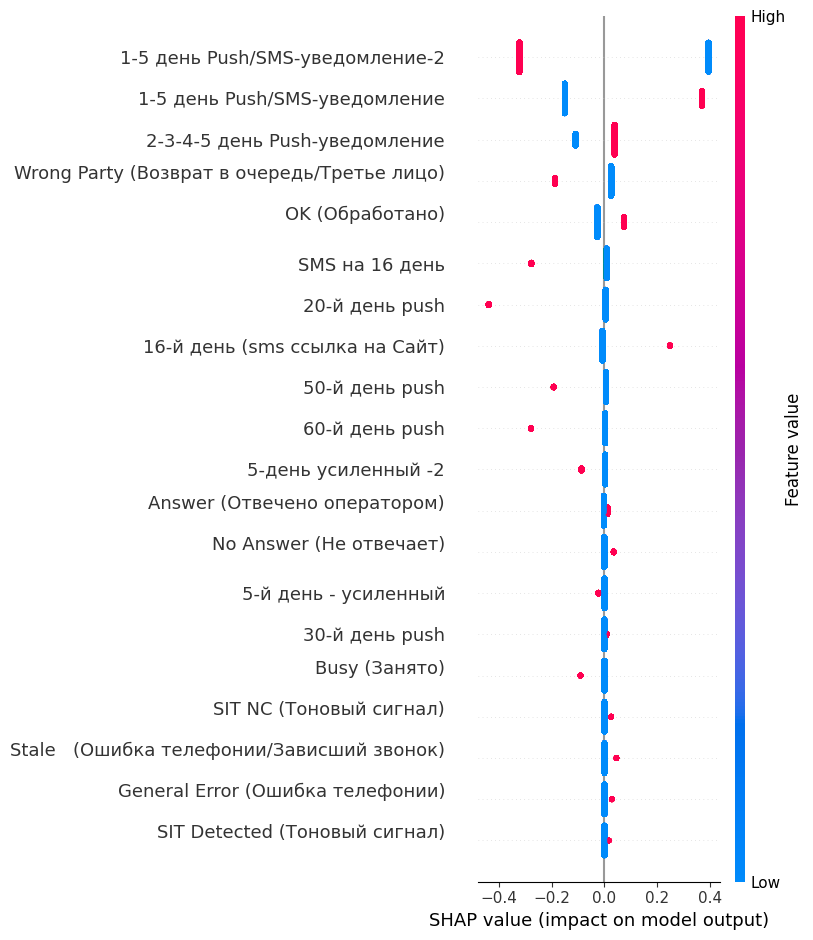

In [74]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)

#### Random classifier test

In [75]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_unique, y_train_counts = np.unique(y_train, return_counts=True)
class_probs = y_train_counts / y_train_counts.sum() 

y_random_pred = np.random.choice(y_train_unique, size=len(y_test), p=class_probs)

accuracy = accuracy_score(y_test, y_random_pred)
precision = precision_score(y_test, y_random_pred, zero_division=0)
recall = recall_score(y_test, y_random_pred, zero_division=0)
f1 = f1_score(y_test, y_random_pred, zero_division=0)

print(f"Random Classifier Performance:\n"
      f"Accuracy: {accuracy:.4f}\n"
      f"Precision: {precision:.4f}\n"
      f"Recall: {recall:.4f}\n"
      f"F1 Score: {f1:.4f}")

Random Classifier Performance:
Accuracy: 0.5057
Precision: 0.4439
Recall: 0.4403
F1 Score: 0.4421


#### Baseline model: majority class

In [76]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent") 
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dummy)
precision = precision_score(y_test, y_pred_dummy, zero_division=0)
recall = recall_score(y_test, y_pred_dummy, zero_division=0)
f1 = f1_score(y_test, y_pred_dummy, zero_division=0)

print(f"Majority Class Dummy:\n"
      f"Accuracy: {accuracy:.4f}\n"
      f"Precision: {precision:.4f}\n"
      f"Recall: {recall:.4f}\n"
      f"F1 Score: {f1:.4f}")

Majority Class Dummy:
Accuracy: 0.5552
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


### 5.2 XGBoost

**To do:**
* Test with both label encoding and one-hot encoding
* Compare cases for different categories of people and different lengths of sequences

In [77]:
data_xgboost = data_model.copy()

#### Preparing the data

In [78]:
data_xgboost['is_reduced'] = data_xgboost['is_reduced'].shift(-1).fillna(0)
data_xgboost['sequence_status'] = data_xgboost['sequence_status'].map({'Incomplete': 0, 'Complete': 1})

In [79]:
max_actions = data_xgboost.groupby('sequence_index')['notificationname'].count().max()

pivoted_data = (
    data_xgboost.groupby('sequence_index')['notificationname']
    .apply(list) 
    .apply(lambda x: x + [None] * (max_actions - len(x)))  
    .apply(pd.Series) 
    .rename(columns=lambda x: f'Action_{x+1}')
)

features = data_xgboost.groupby('sequence_index').first().drop(columns=['notificationname', 'is_reduced', 'notificationtype', 'delay_count_main', 
                                                                        'balance_odue_main_dbt_amt', 'eff_interest_rate', 'balance_odue_int_amt', 'next_payment_date',
                                                                        'comm_date', 'open_date', 'contract_number'
                                                                         ])

final_data = pd.concat([pivoted_data, features], axis=1).reset_index()
groups = final_data['sequence_index'].map(contract_of_sequence)

# final_data

In [80]:
final_data.columns
final_data = final_data.drop(columns = ['sequence_index'])

In [81]:
for col in final_data.select_dtypes(include=["object"]).columns:
    final_data[col] = final_data[col].astype("category")

#### Building the model

In [82]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = final_data.drop(columns=["sequence_status"])  

y = final_data["sequence_status"]

X_train, X_test, y_train, y_test = group_split(X, y, groups)

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",  # logarithmic loss for classification
    "max_depth": 5,  # tree depth
    "learning_rate": 0.1,  # sstep size
    "n_estimators": 100,  # boosting round
}

model = xgb.train(params, dtrain, num_boost_round=100)

y_pred_proba = model.predict(dtest) 
y_pred = [1 if p > 0.5 else 0 for p in y_pred_proba]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

C:\Users\meirz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:35:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6408
ROC-AUC: 0.6746
Precision: 0.6152
Recall: 0.5137
F1 Score: 0.5599


#### Extraction of important features

#### Random classifier test

In [83]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_unique, y_train_counts = np.unique(y_train, return_counts=True)
class_probs = y_train_counts / y_train_counts.sum()  

y_random_pred = np.random.choice(y_train_unique, size=len(y_test), p=class_probs)

accuracy = accuracy_score(y_test, y_random_pred)
precision = precision_score(y_test, y_random_pred, zero_division=0)
recall = recall_score(y_test, y_random_pred, zero_division=0)
f1 = f1_score(y_test, y_random_pred, zero_division=0)

print(f"Random Classifier Performance:\n"
      f"Accuracy: {accuracy:.4f}\n"
      f"Precision: {precision:.4f}\n"
      f"Recall: {recall:.4f}\n"
      f"F1 Score: {f1:.4f}")

Random Classifier Performance:
Accuracy: 0.5024
Precision: 0.4405
Recall: 0.4393
F1 Score: 0.4399


#### Feature importance visualization

### 5.3 Random Forest

In [84]:
data_random_forest = data_model.copy()

In [85]:
data_random_forest['is_reduced'] = data_random_forest['is_reduced'].shift(-1).fillna(0)
data_random_forest['sequence_status'] = data_random_forest['sequence_status'].map({'Incomplete': 0, 'Complete': 1})

In [86]:
from sklearn.preprocessing import LabelEncoder

max_actions = data_random_forest.groupby('sequence_index')['notificationname'].count().max()

pivoted_data = (
    data_random_forest.groupby('sequence_index')['notificationname']
    .apply(list)  # group actions into list for each contract
    .apply(lambda x: x + [None] * (max_actions - len(x)))  # fill missing ones with none
    .apply(pd.Series)  # turn list into separate columns
    .rename(columns=lambda x: f'Action_{x+1}')  # renaming columns
)

features = data_random_forest.groupby('sequence_index').first().drop(columns=['notificationname', 'is_reduced', 'notificationtype', 'delay_count_main', 
                                                                        'balance_odue_main_dbt_amt', 'eff_interest_rate', 'balance_odue_int_amt', 'next_payment_date',
                                                                        'comm_date', 'open_date', 'contract_number'
                                                                         ])

final_data = pd.concat([pivoted_data, features], axis=1).reset_index()
groups = final_data['sequence_index'].map(contract_of_sequence)
final_data = final_data.drop(columns=['sequence_index'])

label_encoder = LabelEncoder()

for column in final_data.select_dtypes(include=['object']).columns:
    final_data[column] = label_encoder.fit_transform(final_data[column])

#### Building the model

Accuracy: 0.6289
ROC-AUC: 0.6607
Precision: 0.6027
Recall: 0.4858
F1 Score: 0.5380


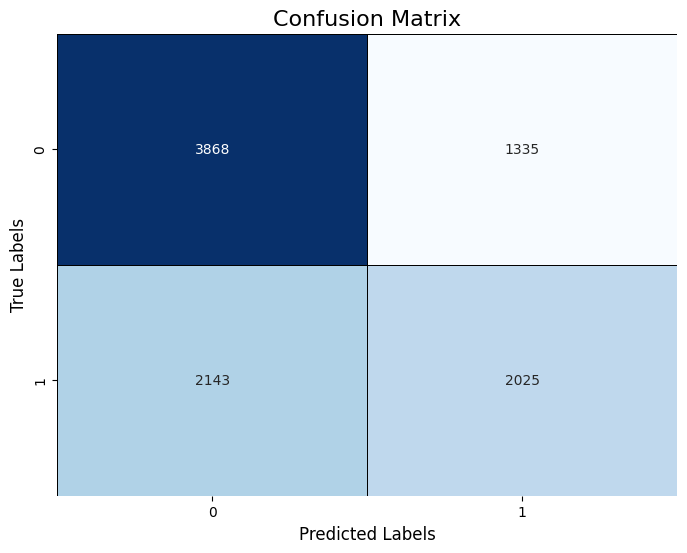

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X = final_data.drop(columns=["sequence_status"])  

y = final_data["sequence_status"]

X_train, X_test, y_train, y_test = group_split(X, y, groups)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)  # n_estimators is the number of trees
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test) # for classification

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1])

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)

# confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5, linecolor='black')

# labels and titles
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)

# displaying the plot
plt.show()